In [5]:
# import pandas as pd
# import glob
# import numpy as np
# from evcouplings.compare import DistanceMap
# from copy import deepcopy
# from scipy.stats import ks_2samp
# import os
# import warnings
# warnings.filterwarnings("ignore")

# import matplotlib.pyplot as plt
# import seaborn as sns

# from evcouplings.visualize.pymol import (
#     pymol_pair_lines, pymol_mapping
# )
# from sklearn.metrics import roc_curve
# from sklearn import metrics

<!-- ## Check whether we've successfully run every job -->

In [7]:
# dataset = pd.read_csv("../data/summary_data/02.structure_hits_filtered.csv", index_col=0)
# output_path= "../data/output"

# problem_uids = []

# for idx, row in dataset.iterrows():
#     #print(row)
    
#     if not os.path.isfile(f"{output_path}/{row.uid}/G_scores.csv"):
#         print(row.uid)
#         problem_uids.append(row.uid)

        
# print(f"{len(problem_uids)} runs failed")

In [8]:
# protein_data = pd.read_csv("../data/summary_data/02.structure_hits_filtered.csv", index_col=0)
# output_path= "../data/output"

# columns_to_add = [

# ]

# NUM_SHUFFLES=10000
# for col in columns_to_add:
#     protein_data[col] = np.nan

# for idx, row in protein_data.iterrows():

#     uid = row.uid
    
#     # if uid != "GYRA_MYCTU":
#     #     continue
    
#     prefix = uid
#     print(uid)

#     entry = row.Entry
    
#     try:
#         scores = pd.read_csv(f"{output_path}/{prefix}/G_scores.csv")
#         mutations = pd.read_csv(f"{output_path}/{prefix}/all_mutations_analyzed.csv")

#         #pvals = pd.read_csv(f"{output_path}/{prefix}/random_GeO_iterations_{NUM_SHUFFLES}.csv.gz", index_col=0, compression="gzip")
#         #full_distr = pd.read_csv(f"{output_path}/{prefix}/random_GeO_full_distribution_{NUM_SHUFFLES}.csv")

#         result_table = pd.read_csv(f"{output_path}/{prefix}/random_GeO_pvalues_{NUM_SHUFFLES}.csv.gz", compression="gzip")
        
#         protein_data.loc[idx, "num_shuffles"] = len(result_table)
#         protein_data.loc[idx, "max_pvalue"] = result_table.pvalue.max()
#         protein_data.loc[idx, "min_pvalue"] = result_table.pvalue.min()
#         protein_data.loc[idx, "median_pvalue"] = np.nanmedian(result_table.pvalue)
#         protein_data.loc[idx, "ks_test_num_significant_0p01"] = len(result_table.query("pvalue < 0.01"))
#         protein_data.loc[idx, "max_GeO"] = scores.G_score.max()
#         protein_data.loc[idx, "selected_pvalue"] = result_table.loc[np.random.randint(0, len(result_table)+1), "pvalue"]
#         protein_data.loc[idx, "total_mutations"] = mutations.summed.sum()
#         protein_data.loc[idx, "max_mutations"] = mutations.summed.max()    
        
#     except:
#         print("ERROR, NO PVALUES FOR", uid)
#         continue


        
        
#     # acquire the distances between the top 2 most mutated sites
#     mutations = pd.read_csv(f"{output_path}/{prefix}/all_mutations_analyzed.csv", index_col=0)

#     dm = DistanceMap.from_file(f"../data/filtered_distmaps/{entry}")

#     try:
#         protein_data.loc[idx, "distance_top_pair"] = dm.dist(mutations.residue.iloc[0], mutations.residue.iloc[1])
#     except:
#         print("Error with finding distance - missing all_mutations_analyzed.csv?")

# protein_data.to_csv("../data/summary_data/03.geo_score_data.csv")

<!-- # Below is exploratory data analysis code -->

In [ ]:
protein_data = pd.read_csv("output/03.geo_score_data.csv")
protein_data.head()

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,min_pvalue,median_pvalue,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
0,0,Y876_MYCTU,P9WKR5,Rv0876c,setA,NaN,NaN,315.0,10000.0,0.990914,4.483280e-18,0.025836,3903.0,4.153813,0.015921,84.0,5.0,1.331764
1,1,Y2076_MYCTU,P9WLL3,Rv2076c,setA,NaN,NaN,6.0,10000.0,1.000000,1.428571e-01,0.474026,0.0,2.098585,0.930736,6.0,3.0,5.025862
2,2,Y037_MYCTU,P9WJY1,Rv0037c,setA,NaN,NaN,402.0,10000.0,0.999664,3.347913e-16,0.003069,6033.0,3.888206,0.000608,248.0,5.0,1.334354
3,3,Y1995_MYCTU,P9WLP3,Rv1995,setA,NaN,NaN,189.0,10000.0,0.999527,2.576583e-13,0.016971,4366.0,3.766406,0.764029,94.0,4.0,6.682337
4,4,Y2012_MYCTU,P9WLM3,Rv2012,setA,NaN,NaN,136.0,10000.0,0.999990,4.420737e-05,0.304222,251.0,2.678325,0.056804,104.0,6.0,1.332983


<!-- ## Are Z-scores a reasonable way to measure significance?  -->

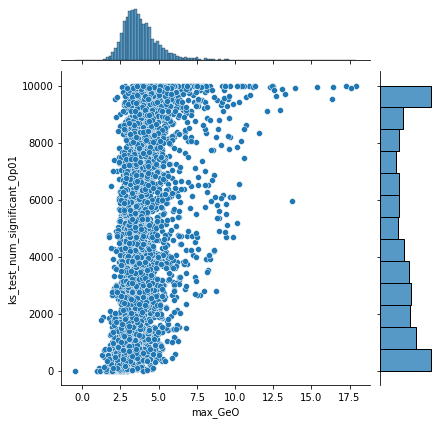

In [ ]:
# sns.jointplot(data=protein_data, x="max_GeO", y="ks_test_num_significant_0p01")

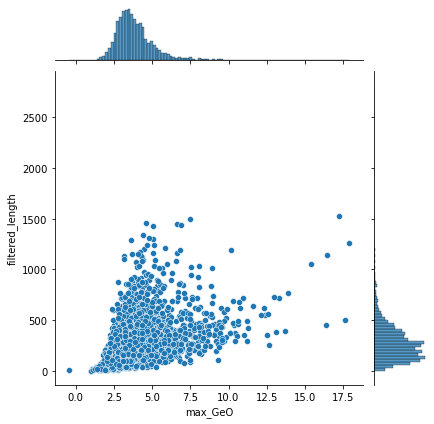

In [ ]:
# sns.jointplot(data=protein_data, x="max_GeO", y="filtered_length")

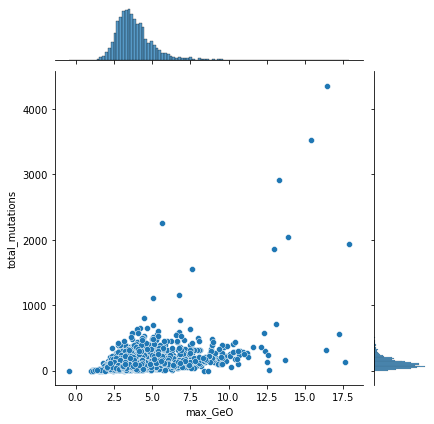

In [ ]:
# sns.jointplot(data=protein_data, x="max_GeO", y="total_mutations")

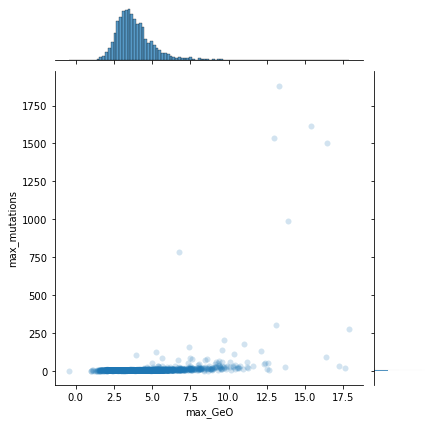

In [ ]:
# sns.jointplot(data=protein_data, x="max_GeO", y="max_mutations", linewidth=0, alpha=0.2)

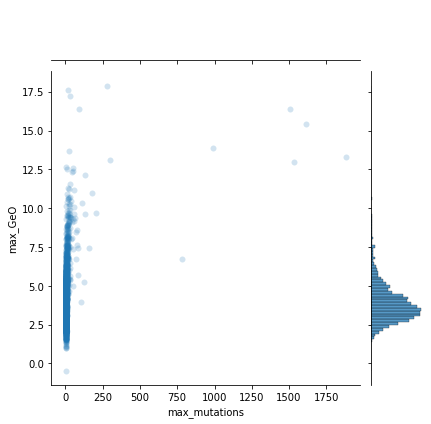

In [ ]:
# sns.jointplot(data=protein_data, x="max_mutations", y="max_GeO", linewidth=0, alpha=0.2)

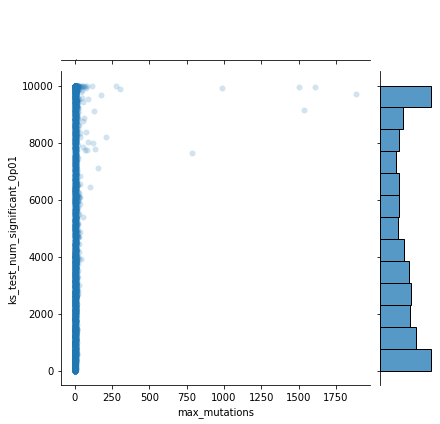

In [ ]:
# sns.jointplot(data=protein_data, x="max_mutations", y="ks_test_num_significant_0p01", linewidth=0, alpha=0.2)

In [ ]:
# to_display = ['uid', 'set', 
#        'filtered_length', 'ks_test_num_significant_0p01', 'median_pvalue', 'max_GeO',
#        'selected_pvalue', 'total_mutations', 'max_mutations',
#        'distance_top_pair']
# protein_data.sort_values("max_mutations", ascending=False).head(50)[to_display]

,uid,set,filtered_length,ks_test_num_significant_0p01,median_pvalue,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
1606,KATG_MYCTU,setB,716.0,9708.0,4.466993e-17,13.281554,4.031058e-35,2917.0,1882.0,1.354466
1619,EMBB_MYCTU,setB,1054.0,9937.0,1.794487e-31,15.387103,2.397650e-110,3518.0,1613.0,1.333597
1738,CAS10_MYCTU,setB,729.0,9145.0,3.517964e-14,12.945597,1.513914e-24,1861.0,1534.0,3.829486
1237,RPOB_MYCTU,setB,1138.0,9940.0,4.252411e-58,16.415010,1.056339e-16,4355.0,1504.0,1.338737
3034,GYRA_MYCTU,setA,766.0,9912.0,1.954858e-22,13.901167,8.670144e-37,2034.0,989.0,1.328667
1122,RS12_MYCTU,setB,122.0,7640.0,4.019369e-07,6.729556,6.512103e-06,1152.0,783.0,9.089187
2980,LLDD_MYCTU,setA,380.0,9879.0,5.502421e-61,13.078278,2.633735e-87,713.0,301.0,1.335717
1091,RPOC_MYCTU,setB,1264.0,10000.0,5.575054e-36,17.895197,2.213936e-27,1940.0,277.0,14.461010
333,O06813_MYCTU,setA,296.0,8212.0,3.594930e-14,9.685140,1.952404e-02,374.0,206.0,4.146189
3494,I6XEK6_MYCTU,setA,349.0,9657.0,3.480693e-76,10.995384,6.711917e-77,261.0,178.0,3.355143


In [ ]:
# to_display = ['uid', 'set', 
#        'filtered_length', 'ks_test_num_significant_0p01', 'median_pvalue', 'max_GeO',
#        'selected_pvalue', 'total_mutations', 'max_mutations',
#        'distance_top_pair']
# protein_data.query("distance_top_pair < 5").sort_values("total_mutations", ascending=False).head(20)[to_display]

,uid,set,filtered_length,ks_test_num_significant_0p01,median_pvalue,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
1237,RPOB_MYCTU,setB,1138.0,9940.0,4.252411e-58,16.415010,1.056339e-16,4355.0,1504.0,1.338737
1619,EMBB_MYCTU,setB,1054.0,9937.0,1.794487e-31,15.387103,2.397650e-110,3518.0,1613.0,1.333597
1606,KATG_MYCTU,setB,716.0,9708.0,4.466993e-17,13.281554,4.031058e-35,2917.0,1882.0,1.354466
1311,PNCA_MYCTU,setB,185.0,9994.0,4.286039e-07,5.669248,5.308479e-05,2256.0,84.0,1.337166
3034,GYRA_MYCTU,setA,766.0,9912.0,1.954858e-22,13.901167,8.670144e-37,2034.0,989.0,1.328667
1738,CAS10_MYCTU,setB,729.0,9145.0,3.517964e-14,12.945597,1.513914e-24,1861.0,1534.0,3.829486
1077,RSMG_MYCTU,setB,202.0,9909.0,1.606737e-06,7.635280,1.043594e-03,1548.0,75.0,1.328516
3324,P71815_MYCTU,setA,438.0,10000.0,7.170900e-15,4.488217,1.102358e-17,803.0,20.0,1.337632
3195,O86335_MYCTU,setA,1196.0,9973.0,1.968367e-14,6.836227,1.006526e-08,780.0,7.0,3.242539
2980,LLDD_MYCTU,setA,380.0,9879.0,5.502421e-61,13.078278,2.633735e-87,713.0,301.0,1.335717


In [ ]:
P71815_MYCTU - histidine kinase phoR
O86335_MYCTU - pks6
LLDD LLDD_MYCTU
O53498_MYCTU cobN
MVINL - probable peptidoglycan biosynthesis protein
MDREP - Multidrug efflux ATP-binding/permease protein Rv0194
	P95223_MYCTU - OplA
Y064_MYCTU - Rv0064
DHE2_MYCTU - gdh myctu
P96937_MYCTU - alpha-mannosidase

In [ ]:
# protein_data.sort_values("median_pvalue", ascending=True).head(20)[to_display]

,uid,set,filtered_length,ks_test_num_significant_0p01,median_pvalue,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
3267,ECCC5_MYCTU,setA,1191.0,10000.0,6.209159e-227,10.141429,1.343144e-241,48.0,4.0,9.328179
3266,ECCC3_MYCTU,setA,1166.0,10000.0,7.768284e-102,6.610906,1.359368e-122,459.0,5.0,6.354922
1108,GLTB_MYCTU,setB,1451.0,10000.0,1.901420e-87,6.627109,6.067186e-104,441.0,5.0,3.704428
3799,I6XEK6_MYCTU,setA,349.0,9657.0,3.480693e-76,10.995384,2.048733e-54,261.0,178.0,3.355143
3333,ACNA_MYCTU,setA,896.0,10000.0,6.538374e-64,4.777139,5.150913e-65,207.0,3.0,3.320379
171,PG30_MYCTU,setA,572.0,10000.0,3.801505e-61,8.390017,1.567489e-62,138.0,5.0,1.328848
3241,LLDD_MYCTU,setA,380.0,9879.0,5.502421e-61,13.078278,2.270081e-113,713.0,301.0,1.335717
1411,RPOB_MYCTU,setB,1138.0,9940.0,4.252411e-58,16.415010,1.633195e-61,4355.0,1504.0,1.338737
166,PG34_MYCTU,setA,388.0,10000.0,7.132642e-58,7.179948,2.566063e-57,87.0,7.0,4.019140
1468,MASZ_MYCTU,setB,715.0,10000.0,1.474137e-57,10.914327,8.451983e-83,286.0,9.0,1.341624


In [ ]:
# protein_data.sort_values("ks_test_num_significant_0p01", ascending=False).head(20)[to_display]

,uid,set,filtered_length,ks_test_num_significant_0p01,median_pvalue,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair
1120,BE_MYCTU,setB,488.0,10000.0,7.682956e-17,4.477214,1.782166e-11,140.0,3.0,3.837129
932,L0TCB8_MYCTU,setA,435.0,10000.0,1.952033e-54,6.984162,1.946171e-53,108.0,4.0,1.333225
1970,O53611_MYCTU,setB,732.0,10000.0,8.492505e-40,6.717609,1.309802e-32,321.0,6.0,13.584573
1284,AFTD_MYCTU,setB,1303.0,10000.0,3.733016e-52,5.030014,5.526252e-42,508.0,6.0,8.272237
29,Y3818_MYCTU,setA,508.0,10000.0,8.191767e-27,4.639541,2.962952e-36,149.0,4.0,14.165245
166,PG34_MYCTU,setA,388.0,10000.0,7.132642e-58,7.179948,2.566063e-57,87.0,7.0,4.019140
1323,SYFA_MYCTU,setB,322.0,10000.0,2.195428e-22,4.074464,5.014295e-13,88.0,3.0,1.336172
33,Y1702_MYCTU,setA,354.0,10000.0,5.510510e-20,12.494063,5.868872e-21,138.0,10.0,1.330040
3267,ECCC5_MYCTU,setA,1191.0,10000.0,6.209159e-227,10.141429,1.343144e-241,48.0,4.0,9.328179
3266,ECCC3_MYCTU,setA,1166.0,10000.0,7.768284e-102,6.610906,1.359368e-122,459.0,5.0,6.354922


In [ ]:
# len(protein_data.ks_test_num_significant_0p01.dropna())

3655

In [ ]:
# for column in ["max_pvalue", "selected_pvalue", "median_pvalue", "min_pvalue"]:

#     protein_data = protein_data.dropna(subset=[column])
#     protein_data["log_" + column] = [-np.log(x) for x in protein_data[column]]
    

In [ ]:
# feature = "ks_test_num_significant_0p01"
# threshold = 9267.0
# distance_threshold = 15


# print(len(protein_data.query("ks_test_num_significant_0p01> @threshold ")), "significant hits")
# print(len(protein_data.query("distance_top_pair < @distance_threshold")), "significant hits")

# print(len(protein_data.query("ks_test_num_significant_0p01 > @threshold and distance_top_pair < @distance_threshold")), "significant hits")
# unfiltered_protein_data = protein_data
# protein_data = protein_data.query("distance_top_pair < @distance_threshold")
# protein_data.to_csv("../data/output/03.geo_score_data.csv")


451 significant hits
3403 significant hits
451 significant hits


In [ ]:
# allmuts = pd.read_csv("../data/summary_data/02.all_mutations_analyzed.csv", index_col=0)

# k = pd.read_csv("../data/summary_data/01.structure_hits.csv")
# k

# grouped = allmuts.groupby("uid").sum()
# total_muts = pd.DataFrame(grouped)

# sites_mutated = pd.DataFrame(allmuts.groupby("uid").size(), columns=["sites_mutated"])
# sites_mutated = sites_mutated.merge(k[["uid", "filtered_length"]], on="uid", how="left")
# sites_mutated["percent"] = sites_mutated.sites_mutated / sites_mutated.filtered_length
# sites_mutated = sites_mutated.merge(total_muts, on="uid", how="left")


In [ ]:
# protein_data = pd.read_csv("../data/output/03.geo_score_data.csv")

# hits = protein_data.query("ks_test_num_significant_0p01 > @threshold")

# #its = protein_data.query("is_sig_BH")

# hits

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,...,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair,log_max_pvalue,log_selected_pvalue,log_median_pvalue,log_min_pvalue
8,9,Y3766_MYCTU,O69731,Rv3766,setA,NaN,NaN,261.0,10000.0,0.005828,...,10000.0,5.302467,1.568056e-18,173.0,10.0,3.555472,5.145045,40.996695,45.274393,96.141846
22,24,Y3193_MYCTU,P9WFL3,Rv3193c,setA,NaN,NaN,918.0,10000.0,0.348290,...,9989.0,4.297506,1.745238e-25,257.0,5.0,1.335291,1.054719,57.007737,57.518272,128.987171
23,26,Y738_MYCTU,P9WKS3,Rv0738,setA,NaN,NaN,181.0,10000.0,0.822669,...,9698.0,3.588393,1.753094e-04,46.0,3.0,1.348844,0.195201,8.648958,11.617426,20.918272
26,29,Y3818_MYCTU,P9WH21,Rv3818,setA,NaN,NaN,508.0,10000.0,0.001657,...,10000.0,4.639541,2.962952e-36,149.0,4.0,14.165245,6.403017,81.806877,60.066668,123.456295
27,30,Y1735_MYCTU,P9WLS5,Rv1735c,setA,NaN,NaN,60.0,10000.0,0.999486,...,9538.0,3.903826,1.936037e-05,11.0,1.0,9.615414,0.000515,10.852282,9.953283,11.791830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3357,3934,O53896_MYCTU,O53896,Rv0983,setA,NaN,NaN,292.0,10000.0,0.891217,...,9393.0,3.556858,1.712656e-13,91.0,5.0,1.334417,0.115167,29.395561,14.328162,48.293654
3361,3938,I6YGX9_MYCTU,I6YGX9,Rv3692,setA,NaN,NaN,315.0,10000.0,0.683392,...,9900.0,4.355972,9.147149e-05,112.0,3.0,3.333087,0.380687,9.299483,21.943344,60.823191
3367,3946,Q1LVD4_MYCTU,Q1LVD4,Rv3918c,setA,NaN,NaN,276.0,10000.0,0.743564,...,9922.0,5.802902,1.512024e-07,116.0,6.0,6.766142,0.296301,15.704646,21.035996,47.740004
3397,3981,I6YCQ4_MYCTU,I6YCQ4,Rv3670,setA,NaN,NaN,307.0,10000.0,0.946537,...,9412.0,4.891813,1.613520e-10,104.0,6.0,6.154778,0.054946,22.547433,15.849194,56.939026


In [ ]:
# protein_data

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,...,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair,log_max_pvalue,log_selected_pvalue,log_median_pvalue,log_min_pvalue
0,0,Y876_MYCTU,P9WKR5,Rv0876c,setA,NaN,NaN,315.0,10000.0,0.990914,...,3903.0,4.153813,3.203410e-01,84.0,5.0,1.331764,0.009127,1.138369,3.655997,39.946177
1,1,Y2076_MYCTU,P9WLL3,Rv2076c,setA,NaN,NaN,6.0,10000.0,1.000000,...,0.0,2.098585,9.307359e-01,6.0,3.0,5.025862,-0.000000,0.071780,0.746493,1.945910
2,2,Y037_MYCTU,P9WJY1,Rv0037c,setA,NaN,NaN,402.0,10000.0,0.999664,...,6033.0,3.888206,1.825247e-03,248.0,5.0,1.334354,0.000336,6.306040,5.786365,35.633024
3,3,Y1995_MYCTU,P9WLP3,Rv1995,setA,NaN,NaN,189.0,10000.0,0.999527,...,4366.0,3.766406,4.338354e-03,94.0,4.0,6.682337,0.000473,5.440260,4.076222,28.987142
4,4,Y2012_MYCTU,P9WLM3,Rv2012,setA,NaN,NaN,136.0,10000.0,0.999990,...,251.0,2.678325,7.804071e-02,104.0,6.0,1.332983,0.000010,2.550525,1.189998,10.026619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3398,3982,I6YGS7_MYCTU,I6YGS7,Rv3622c,setA,NaN,NaN,97.0,10000.0,0.999998,...,859.0,3.090586,5.632950e-01,55.0,4.0,1.332093,0.000002,0.573952,1.624570,11.415956
3399,3983,O05878_MYCTU,O05878,Rv3233c,setA,NaN,NaN,165.0,10000.0,0.998505,...,683.0,3.055839,4.208665e-01,72.0,3.0,3.337802,0.001496,0.865440,1.271085,18.634664
3400,3984,I6Y9H2_MYCTU,I6Y9H2,Rv2499c,setA,NaN,NaN,158.0,10000.0,0.997913,...,1580.0,3.095234,6.608056e-03,71.0,5.0,3.879584,0.002089,5.019466,1.837708,32.270654
3401,3986,L7N662_MYCTU,L7N662,Rv1623c,setA,NaN,NaN,455.0,10000.0,0.718239,...,9914.0,5.568935,9.963954e-13,141.0,6.0,4.903516,0.330953,27.634632,28.657456,79.269126


In [ ]:
# sites_mutated["significant_hit"] = [x in list(hits.uid) for x in sites_mutated.uid]
# sites_mutated = sites_mutated.sort_values("significant_hit", ascending=True)


mkdir: cannot create directory ‘figures’: File exists


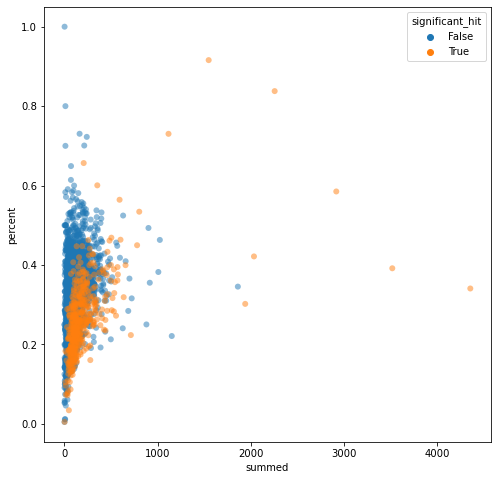

In [ ]:
# !mkdir figures
# figure = plt.figure(figsize=(8,8))

# sns.scatterplot(data=sites_mutated, x="summed", y="percent", alpha=0.5, linewidth=0,hue="significant_hit" )
# #plt.xscale("log")
# plt.savefig("../figures/mutations_versus_percen_with_hits.pdf")

In [ ]:
# protein_data.query("uid=='ETHA_MYCTU'")

,Unnamed: 0,uid,Entry,rv,set,pdb_id,pdb_chain,filtered_length,num_shuffles,max_pvalue,...,ks_test_num_significant_0p01,max_GeO,selected_pvalue,total_mutations,max_mutations,distance_top_pair,log_max_pvalue,log_selected_pvalue,log_median_pvalue,log_min_pvalue
2856,3350,ETHA_MYCTU,P9WNF9,Rv3854c,setA,NaN,NaN,482.0,10000.0,0.043107,...,9998.0,5.029142,1.594664e-13,1117.0,23.0,10.193091,3.144074,29.466943,28.459648,70.481967


In [ ]:
# sites_mutated

,uid,sites_mutated,filtered_length,percent,residue,summed,significant_hit
0,34KD_MYCTU,34,107.0,0.317757,3495,46.0,False
2342,P95286_MYCTU,95,238.0,0.399160,11766,127.0,False
2343,P95287_MYCTU,92,228.0,0.403509,12741,127.0,False
2344,P95289_MYCTU,7,12.0,0.583333,117,10.0,False
2345,P95290_MYCTU,156,384.0,0.406250,35646,218.0,False
...,...,...,...,...,...,...,...
1516,O06551_MYCTU,96,266.0,0.360902,14236,133.0,True
818,I6Y778_MYCTU,135,409.0,0.330073,30540,183.0,True
1099,LLDD_MYCTU,85,380.0,0.223684,15123,713.0,True
1182,MENF_MYCTU,82,361.0,0.227147,13575,100.0,True


In [ ]:
# sites_mutated.sort_values("summed").query("significant_hit").head(10)

,uid,sites_mutated,filtered_length,percent,residue,summed,significant_hit
220,CSM6_MYCTU,2,390.0,0.005128,441,2.0,True
3283,Y1735_MYCTU,11,60.0,0.183333,1133,11.0,True
2668,Q6MWV6_MYCTU,9,86.0,0.104651,120,11.0,True
1261,MRAZ_MYCTU,13,135.0,0.096296,1081,15.0,True
3270,Y1549_MYCTU,10,135.0,0.074074,537,16.0,True
2142,P71646_MYCTU,15,94.0,0.159574,1328,23.0,True
3563,Y474_MYCTU,20,112.0,0.178571,1670,25.0,True
3320,Y1993_MYCTU,20,82.0,0.243902,522,28.0,True
1839,O53400_MYCTU,24,83.0,0.289157,1718,30.0,True
681,I6XEF1_MYCTU,23,319.0,0.072100,3550,33.0,True


In [ ]:
# sites_mutated.sort_values("summed", ascending=False).query("significant_hit").head(10)

,uid,sites_mutated,filtered_length,percent,residue,summed,significant_hit
2836,RPOB_MYCTU,388,1138.0,0.340949,216309,4355.0,True
367,EMBB_MYCTU,413,1054.0,0.391841,224256,3518.0,True
977,KATG_MYCTU,419,716.0,0.585196,158315,2917.0,True
2545,PNCA_MYCTU,155,185.0,0.837838,14355,2256.0,True
551,GYRA_MYCTU,323,766.0,0.421671,131333,2034.0,True
2837,RPOC_MYCTU,382,1264.0,0.302215,257644,1940.0,True
2876,RSMG_MYCTU,185,202.0,0.915842,20890,1548.0,True
413,ETHA_MYCTU,352,482.0,0.730290,84947,1117.0,True
2191,P71815_MYCTU,234,438.0,0.534247,48435,803.0,True
2100,O86335_MYCTU,538,1196.0,0.449833,337977,780.0,True


In [ ]:
# hits.sort_values("ks_test_num_significant_0p01", ascending=False).to_csv("../data/summary_data/ks_test_hits.csv")

In [ ]:
# 